# Sequential CTTA: IDRiD → APTOS → IDRiD (VisionFM)

Protocol:
1. Load VisionFM pretrained weights
2. Evaluate baseline on source domain (IDRiD)
3. Adapt to target domain (APTOS) - adaptation mode
4. Evaluate on ALL previous domains (IDRiD, APTOS) - TEST mode

This measures catastrophic forgetting: after adapting to APTOS,
how much performance degrades on IDRiD?

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [ ]:
config = load_config('configs/method/sequential/cotta/idrid_aptos_visionfm.yaml')

print('Protocol: Sequential CTTA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Model:', config.model.name)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):    import getpass    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')    os.environ['HF_TOKEN'] = token    print('HF_TOKEN set')elif config.model.name != 'retfound':    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential CTTA
Source: idrid
Targets: ['aptos2019']
Method: cotta
Model: visionfm
Output: ./outputs/sequential_cotta/idrid_aptos_visionfm/
HF_TOKEN set


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-07-29 13:46:10,032 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: idrid -> aptos2019
2026-07-29 13:46:10,331 - src.models.visionfm_download - INFO - Downloading VisionFM Fundus weights from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4
From (redirected): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4&confirm=t&uuid=a077e062-3578-4f5a-b682-2d515ee72269
To: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
100%|██████████| 1.51G/1.51G [00:26<00:00, 57.7MB/s]

2026-07-29 13:46:38,380 - src.models.visionfm_download - INFO - VisionFM Fundus weights downloaded to ./cache/visionfm/VFM_Fundus_weights.pth


2026-07-29 13:46:39,627 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-07-29 13:46:40,610 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-07-29 13:46:40,612 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-07-29 13:46:40,674 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-07-29 13:46:40,712 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-07-29 13:46:40,713 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-07-29 13:46:41,108 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-07-29 13:47:01,179 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=50.0
2026-07-29 13:47:01,181 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 413 training samples (5 classes, 3072-dim features, T=50.0)
20

Adapting to idrid:   0%|          | 0/7 [00:00<?, ?it/s]

...

Adapting to aptos2019:  96%|█████████▌| 22/23 [01:15<00:03,  3.54s/it, acc=0.1250, adaptations=22]

2026-07-29 13:49:06,133 - src.evaluation.runner.sequential - INFO -   Adapt step 22: loss=0.0430, kl=0.1176, conf_samples=7, teacher_max_prob=0.7706


Adapting to aptos2019: 100%|██████████| 23/23 [01:19<00:00,  3.44s/it, acc=0.1429, adaptations=23]

2026-07-29 13:49:06,311 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on aptos2019


2026-07-29 13:49:23,622 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.5197
2026-07-29 13:49:23,624 - src.evaluation.runner.sequential - INFO - Adaptations: 23/23
2026-07-29 13:49:23,727 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 2 seen domains after adapting to aptos2019
2026-07-29 13:49:23,728 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on idrid (no adaptation)
2026-07-29 13:49:29,538 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.5093
2026-07-29 13:49:47,020 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.5197
2026-07-29 13:49:47,021 - src.evaluation.runner.sequential - INFO - 
2026-07-29 13:49:47,022 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summary
2026-07-29 13:49:47,023 - src.evaluation.runner.sequential - INFO - ============================================================
2026-07-29 13:49:47,025 - src.evaluation.runner.sequential - INFO - Baseline QWK (id

============== Sequential CTTA Results (CoTTA VisionFM) ==============

Source domain: idrid
  Baseline QWK:           0.4937
  Baseline Overall Acc:   36.89%

Target domains: aptos2019

----------------------------------------------------------------------
After adapting to source idrid (7/7 batches):
  QWK:                  0.5024  (delta: +0.0088)
  Overall Acc:          37.86% (delta: +0.97pp)

----------------------------------------------------------------------
After adapting to aptos2019 (23/23 batches):
  Post-adaptation QWK on aptos2019: 0.5197
  Post-adaptation Acc on aptos2019: 18.85%
  Test on idrid:
    QWK: 0.5093  (delta vs baseline: +0.0157)
    Acc: 35.92% (delta vs baseline: -0.97pp)

  -- Standalone comparison for aptos2019 --



/kaggle/working/medical_CTTA/src/viz/sequential.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc="lower right")


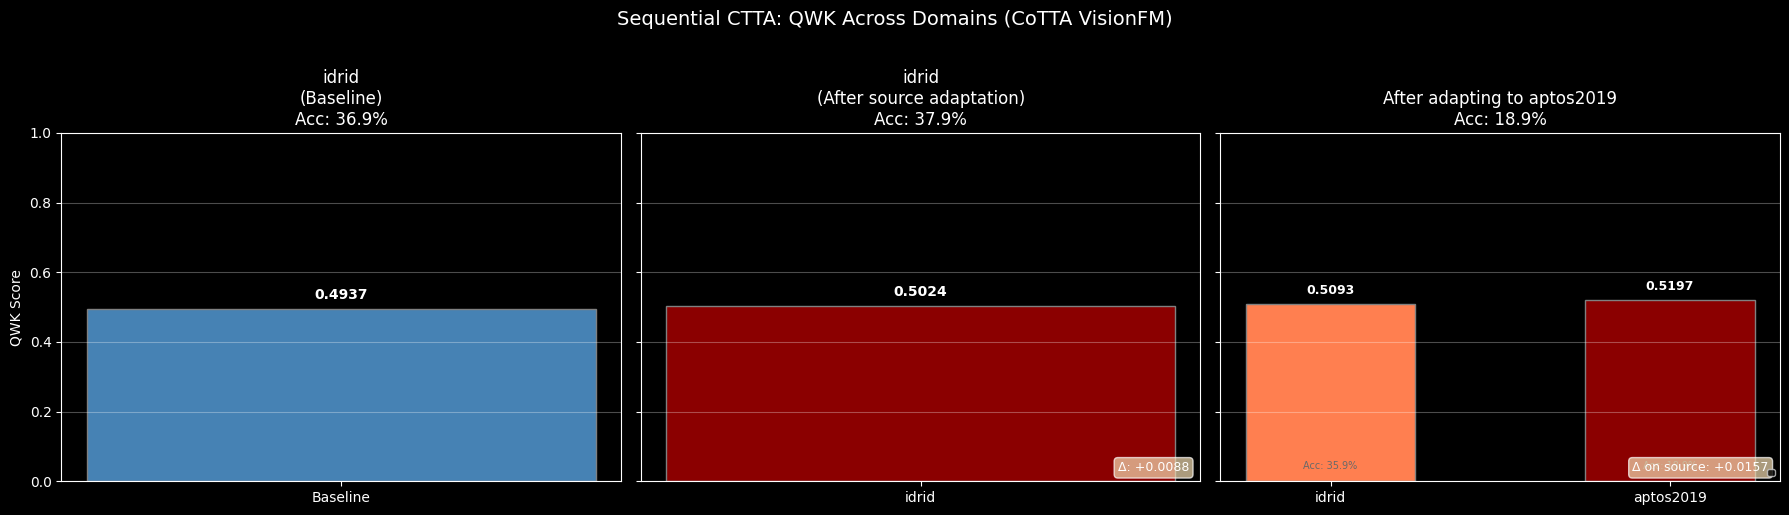

/kaggle/working/medical_CTTA/src/viz/sequential.py:202: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc="lower right")


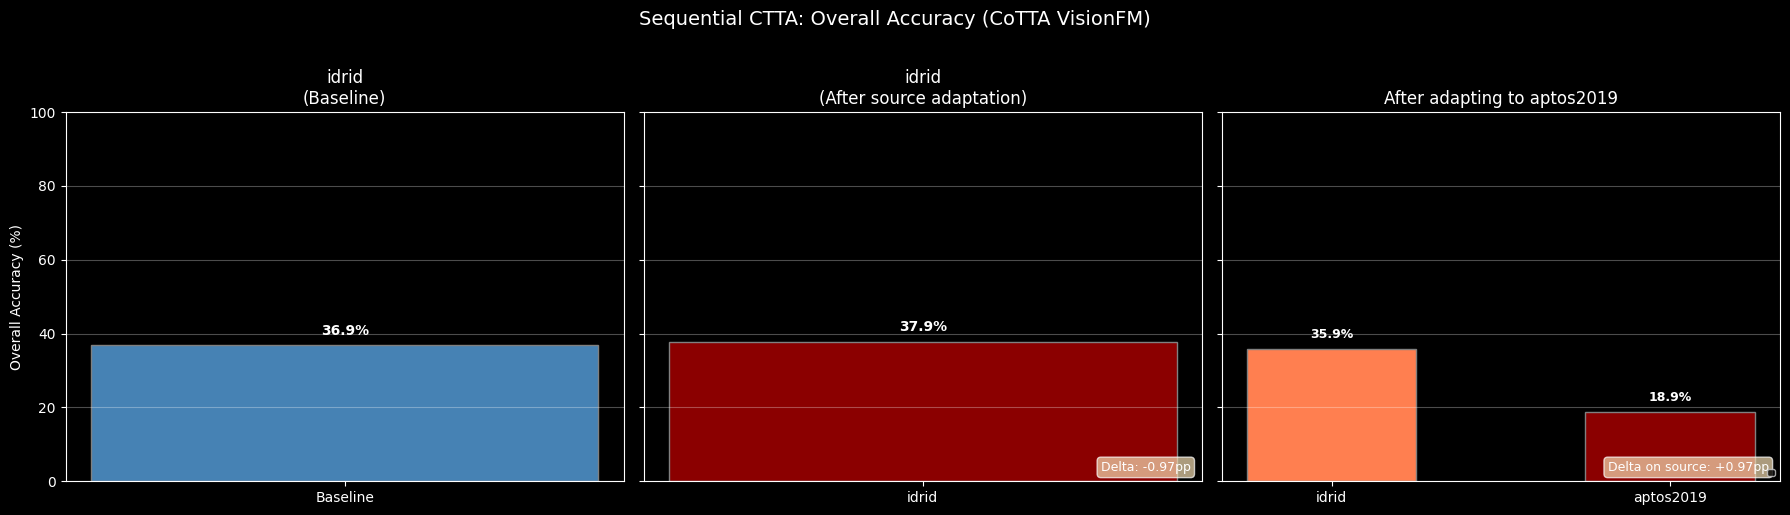

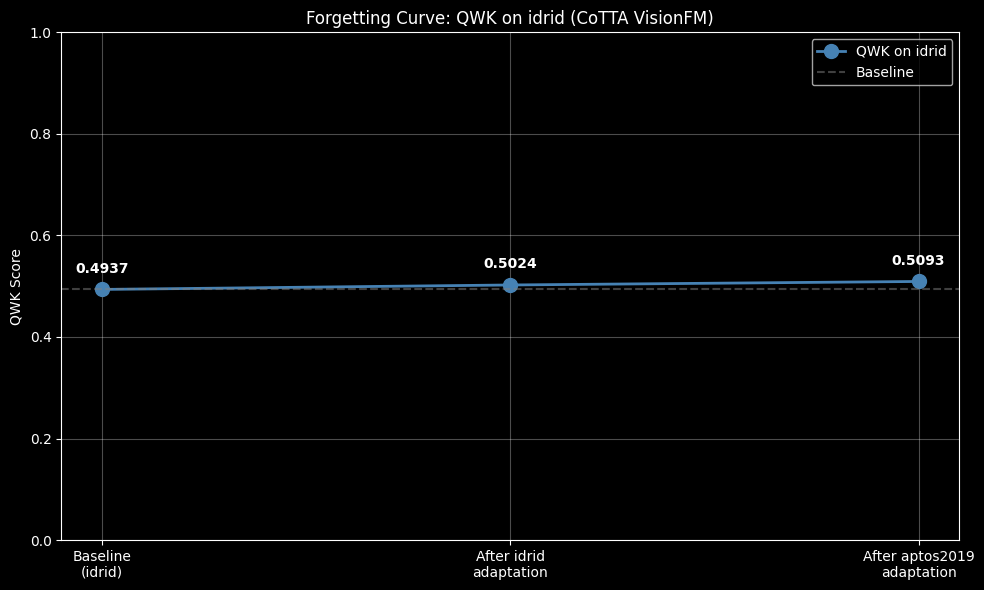

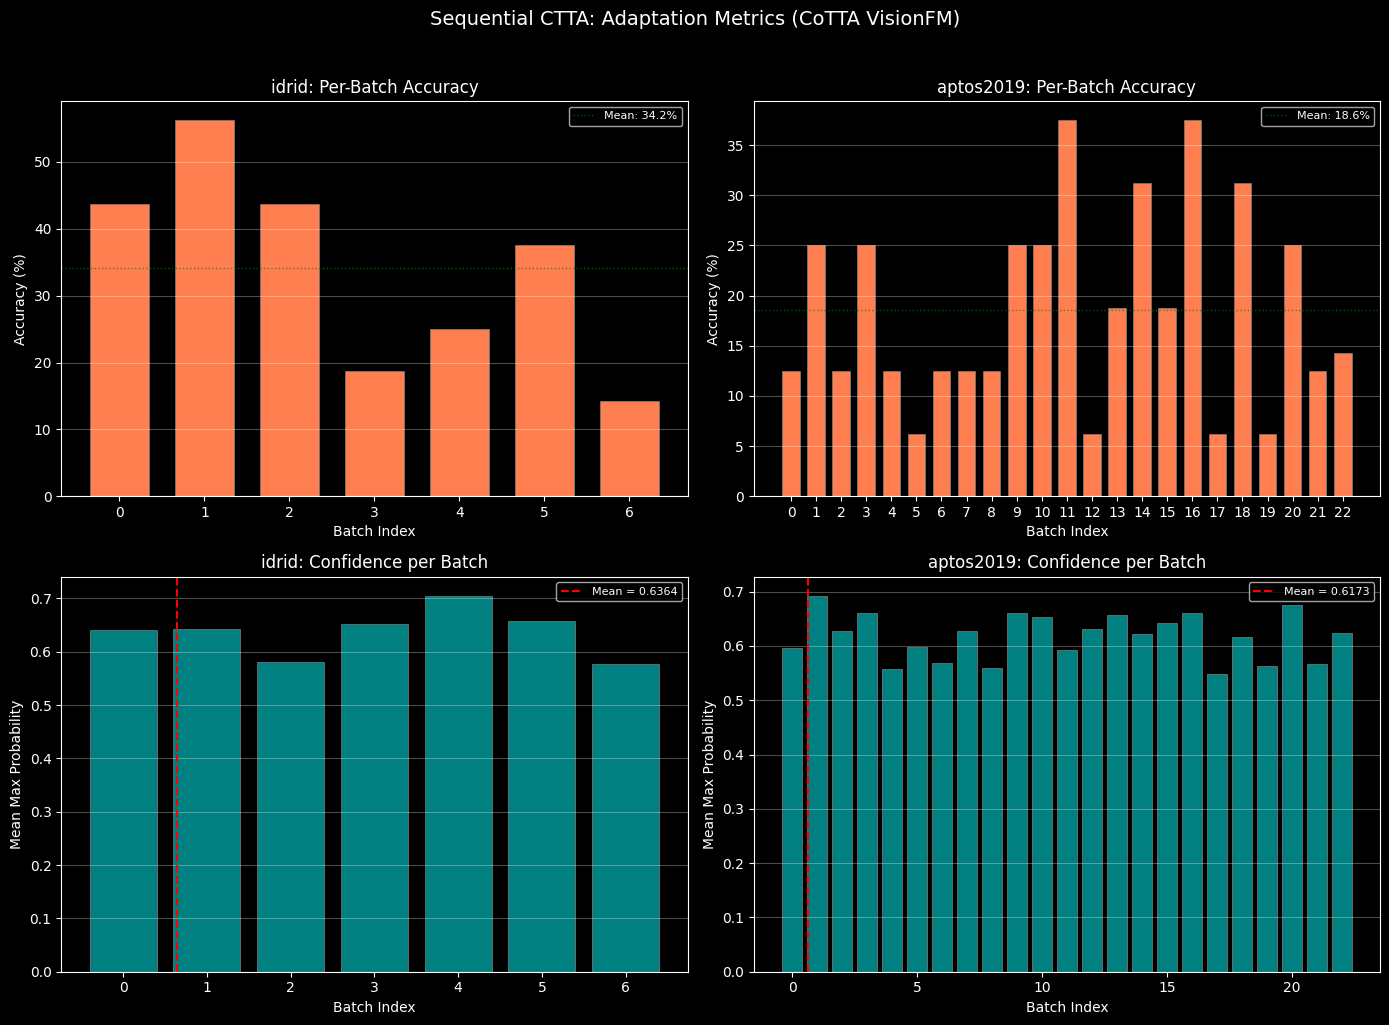

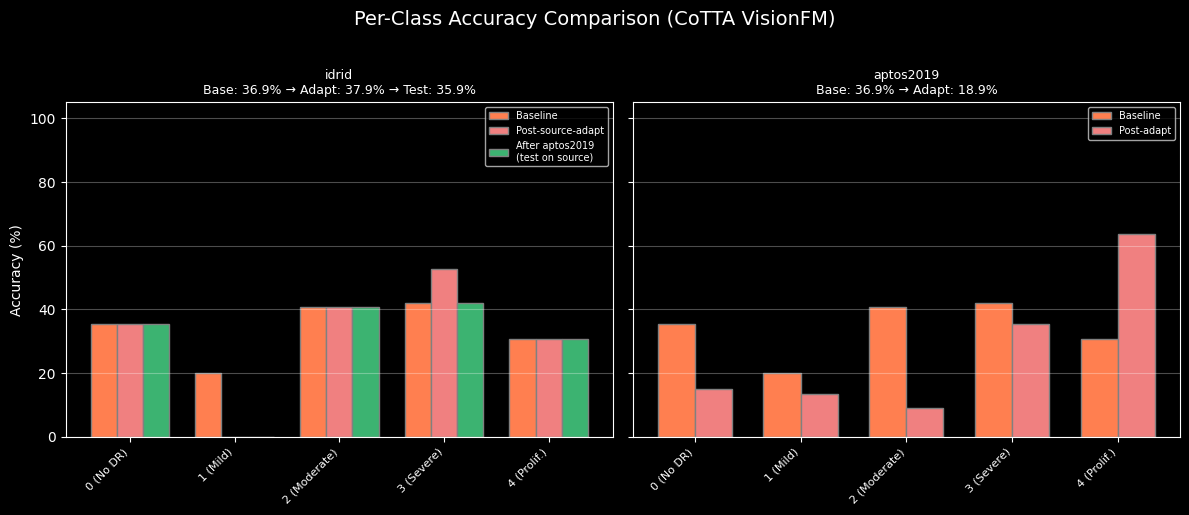

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

idrid_ref = load_standalone_results(
    r"C:\Users\User\My Files\CRNS\visionfm results\cotta_idrid_visionfm_everybatch_v4\ctta_results.json"
)
standalone_references = {"VisionFM (standalone)": idrid_ref}

print_sequential_summary(results, method_name='CoTTA VisionFM', standalone_references=standalone_references)
plot_sequential_qwk_comparison(results, plots_dir, method_name='CoTTA VisionFM', standalone_references=standalone_references)
plot_sequential_overall_accuracy(results, plots_dir, method_name='CoTTA VisionFM', standalone_references=standalone_references)
plot_sequential_forgetting(results, plots_dir, method_name='CoTTA VisionFM')
plot_sequential_adaptation_comparison(results, plots_dir, method_name='CoTTA VisionFM')
plot_sequential_per_class_accuracy(results, plots_dir, method_name='CoTTA VisionFM', standalone_references=standalone_references)